# Exploratory Data Analysis (EDA)
**Project**: House Price Prediction  
**Notebook**: `02_exploratory_data_analysis.ipynb`

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

data_path = os.path.join("..", "data", "raw", "House_Prices.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw", "House_Prices.csv")

df = pd.read_csv(data_path).iloc[:1460]
df = df[df["GrLivArea"] < 4000].reset_index(drop=True)

print("Dataset Loaded for EDA. Shape:", df.shape)

Dataset Loaded for EDA. Shape: (1456, 81)


## 1. Target Variable (`SalePrice`) Distribution

SalePrice Summary Statistics:
count      1456.000000
mean     180151.233516
std       76696.592530
min       34900.000000
25%      129900.000000
50%      163000.000000
75%      214000.000000
max      625000.000000
Name: SalePrice, dtype: float64


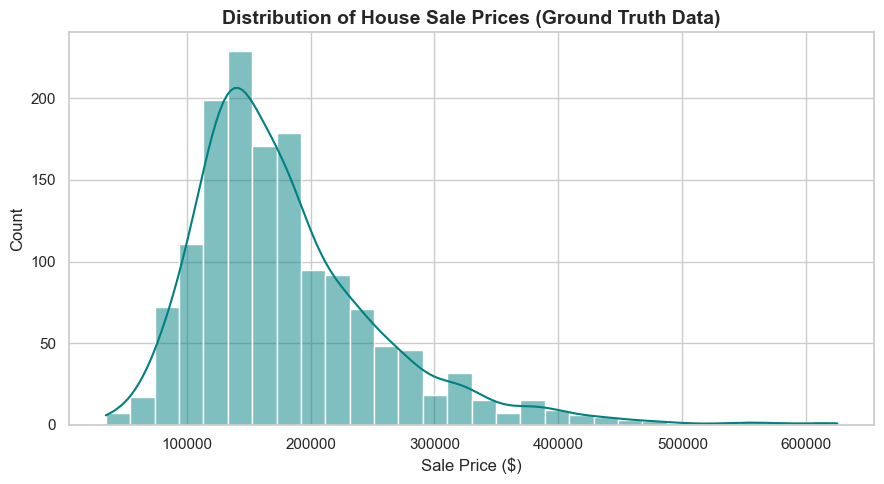

In [2]:
print("SalePrice Summary Statistics:")
print(df["SalePrice"].describe())

plt.figure(figsize=(9, 5))
sns.histplot(df["SalePrice"], kde=True, color="teal", bins=30)
plt.title("Distribution of House Sale Prices (Ground Truth Data)", fontsize=14, fontweight='bold')
plt.xlabel("Sale Price ($)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Living Area (`GrLivArea`) vs `SalePrice`

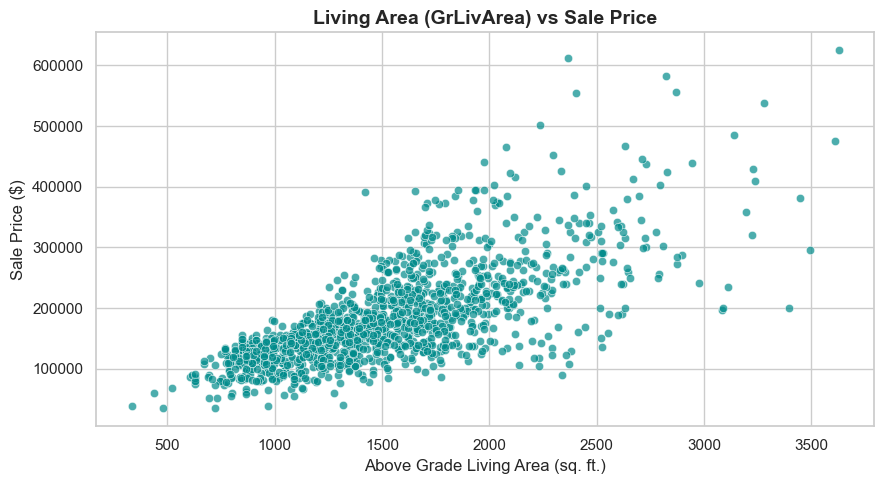

In [3]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", alpha=0.7, color="darkcyan")
plt.title("Living Area (GrLivArea) vs Sale Price", fontsize=14, fontweight='bold')
plt.xlabel("Above Grade Living Area (sq. ft.)", fontsize=12)
plt.ylabel("Sale Price ($)", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Overall Quality (`OverallQual`) vs `SalePrice`

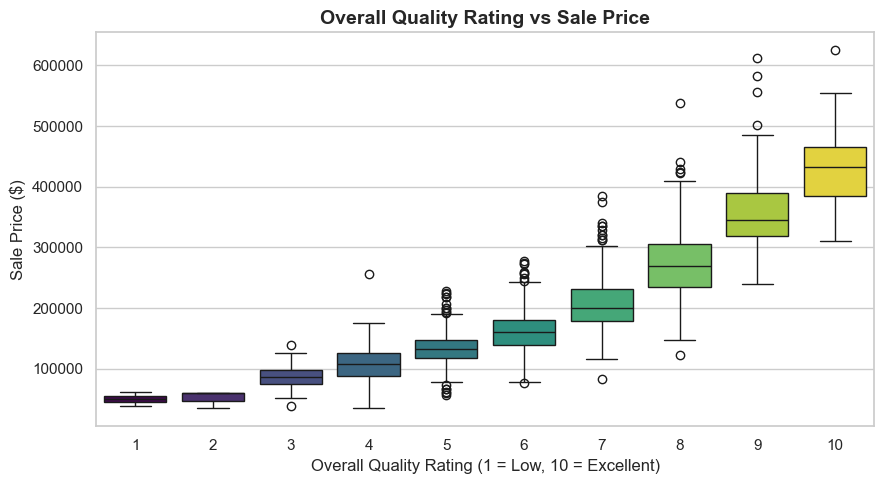

In [4]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="OverallQual", y="SalePrice", hue="OverallQual", palette="viridis", legend=False)
plt.title("Overall Quality Rating vs Sale Price", fontsize=14, fontweight='bold')
plt.xlabel("Overall Quality Rating (1 = Low, 10 = Excellent)", fontsize=12)
plt.ylabel("Sale Price ($)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Top Feature Correlation Heatmap

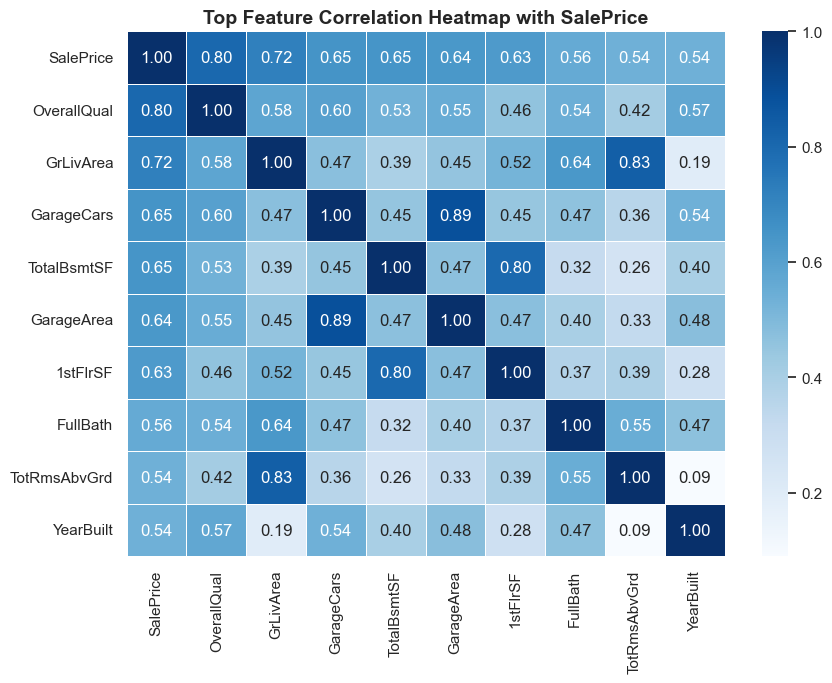

In [5]:
numeric_df = df.select_dtypes(include=[np.number])
top_features = numeric_df.corr()["SalePrice"].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df[top_features].corr(), annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Top Feature Correlation Heatmap with SalePrice", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()